# Intro

## Global parameters

In [1]:
MAX_TIME_HOURS=1

## Modules

In [2]:
import os, pickle, platform, sys
import numpy as np

In [3]:
from collections import defaultdict

In [4]:
import dcms
from dcms.models import DCMModel, DECMModel, qDECMModel, DWCMModel

In [5]:
import matplotlib.pyplot as plt

In [6]:
from scipy.stats import spearmanr

In [7]:
from auxiliary_functions import el2ks

In [8]:
import datetime as dt

## Load data

In [9]:
if platform.system() == 'Darwin':
    print('Air!')
    HOME = '/Users/fabio/Documents/Lavoro/PythonFiles/bowtie2_py310/bowtie2/'
elif platform.system() == 'Linux':
    print('Stella!')
    HOME = '/home/sarawalk/bowtie2_py39/bowtie2/'
else:
    raise RuntimeError(f"Unsupported OS: {platform.system()}")


Air!


In [10]:
sys.path.insert(0, HOME)

In [11]:
DATA_FOLDER=HOME+'dati_elezioni/'

### Original data

In [12]:
files=os.listdir(DATA_FOLDER)
files.sort()

In [13]:
files

['crisi_dicos.csv',
 'crisi_weighted_edgelist.csv',
 'ita_elections_dicos.csv',
 'ita_elections_weighted_edgelist.csv',
 'quirinale_dicos.csv',
 'quirinale_weighted_edgelist.csv']

In [14]:
l_dataset=len(files)//2

### Processed data

In [15]:
TEST_FOLDER=HOME+'tests/'

In [16]:
qdecm_test_files=[file for file in os.listdir(TEST_FOLDER) if file.endswith('_qdecm.pkl')]
qdecm_test_files.sort()
qdecm_test_files

['crisi_dico0_qdecm.pkl',
 'crisi_dico1_qdecm.pkl',
 'crisi_dico2_qdecm.pkl',
 'crisi_dico3_qdecm.pkl',
 'crisi_dico4_qdecm.pkl',
 'ita_elections_dico0_qdecm.pkl',
 'ita_elections_dico1_qdecm.pkl',
 'ita_elections_dico2_qdecm.pkl',
 'ita_elections_dico3_qdecm.pkl',
 'ita_elections_dico4_qdecm.pkl',
 'ita_elections_dico5_qdecm.pkl',
 'ita_elections_dico6_qdecm.pkl',
 'quirinale_dico0_qdecm.pkl',
 'quirinale_dico1_qdecm.pkl',
 'quirinale_dico2_qdecm.pkl',
 'quirinale_dico3_qdecm.pkl',
 'quirinale_dico4_qdecm.pkl',
 'quirinale_dico5_qdecm.pkl',
 'quirinale_dico6_qdecm.pkl']

# Status of the convergence

In [17]:
#import sys
# Mapping per compatibilità con i vecchi pickle salvati con dcms.models.adecm
#sys.modules['dcms.models.adecm'] = dcms.models.qdecm
#sys.modules['dcms.models.ADECMModel'] = dcms.models.qDECMModel

In [18]:
solved=0
models=[]
solved_dataset={}

for file in qdecm_test_files:
    file_mtime = dt.date.fromtimestamp(os.path.getmtime(TEST_FOLDER+file))
    if file_mtime != dt.date.today():
        print(f'[{dt.datetime.now():%Y-%m-%d %H:%M:%S}] The file {file} was not created/modified today. Skipping...')
        continue
    key=file.split('_')[0]
    if key not in solved_dataset.keys():
        solved_dataset[key]={'comms':0, 'solved':0}
    with open(TEST_FOLDER+file, 'rb') as f:
        cacca=pickle.load(f)
    
    if hasattr(cacca, 'sol_weights') and hasattr(cacca.sol_weights, 'converged'):
        models.append(cacca)
        solved_dataset[key]['comms']+=1
        if cacca.sol_weights.converged:
            solved+=1
            solved_dataset[key]['solved']+=1
print(f'{solved}/{len(models)} solved ({solved/len(models)*100:.2f}%)')
for key, value in solved_dataset.items():
    print(f'{key:10}: {value["solved"]}/{value["comms"]} solved ({value["solved"]/value["comms"]*100:.2f}%)')

14/19 solved (73.68%)
crisi     : 4/5 solved (80.00%)
ita       : 6/7 solved (85.71%)
quirinale : 4/7 solved (57.14%)


In [19]:
solved=0
models=[]
solved_dataset={}
file_mask=np.zeros(len(qdecm_test_files), dtype=bool)
for i_file, file in enumerate(qdecm_test_files):
    file_mtime = dt.date.fromtimestamp(os.path.getmtime(TEST_FOLDER+file))
    if file_mtime != dt.date.today():
        print(f'[{dt.datetime.now():%Y-%m-%d %H:%M:%S}] The file {file} was not created/modified today. Skipping...')
        continue
    key=file.split('_')[0]
    if key not in solved_dataset.keys():
        solved_dataset[key]={'solved':0, 'comms':0}
    with open(TEST_FOLDER+file, 'rb') as f:
        model=pickle.load(f)
    
    if hasattr(model, 'sol_weights') and hasattr(model.sol_weights, 'converged'):
        models.append(model)
        file_mask[i_file]=True
        solved_dataset[key]['comms']+=1
        print(f'{file:30} N={model.N:6,d}, weights={model.sol_weights.converged:}')
        if model.sol_weights.converged:
            solved+=1
            solved_dataset[key]['solved']+=1
print(f'{solved}/{len(models)} solved ({solved/len(models)*100:.2f}%)')

crisi_dico0_qdecm.pkl          N=58,832, weights=False
crisi_dico1_qdecm.pkl          N=31,874, weights=True
crisi_dico2_qdecm.pkl          N=15,168, weights=True
crisi_dico3_qdecm.pkl          N= 1,304, weights=True
crisi_dico4_qdecm.pkl          N= 3,637, weights=True
ita_elections_dico0_qdecm.pkl  N=50,288, weights=True
ita_elections_dico1_qdecm.pkl  N=107,056, weights=False
ita_elections_dico2_qdecm.pkl  N=20,914, weights=True
ita_elections_dico3_qdecm.pkl  N=28,156, weights=True
ita_elections_dico4_qdecm.pkl  N= 9,010, weights=True
ita_elections_dico5_qdecm.pkl  N=   373, weights=True
ita_elections_dico6_qdecm.pkl  N=   337, weights=True
quirinale_dico0_qdecm.pkl      N=33,244, weights=True
quirinale_dico1_qdecm.pkl      N=11,045, weights=False
quirinale_dico2_qdecm.pkl      N=18,704, weights=True
quirinale_dico3_qdecm.pkl      N= 3,000, weights=True
quirinale_dico4_qdecm.pkl      N=22,754, weights=False
quirinale_dico5_qdecm.pkl      N=27,746, weights=False
quirinale_dico6_qdecm.

In [20]:
qdecm_test_files=np.array(qdecm_test_files)[file_mask]

In [21]:
color_dict={'crisi': 'navy', 'ita': 'darkcyan', 'quirinale': 'orange'}

In [22]:
Ns=np.array([model.N for model in models])
res_final=np.array([model.sol_weights.residuals[-1] for model in models])

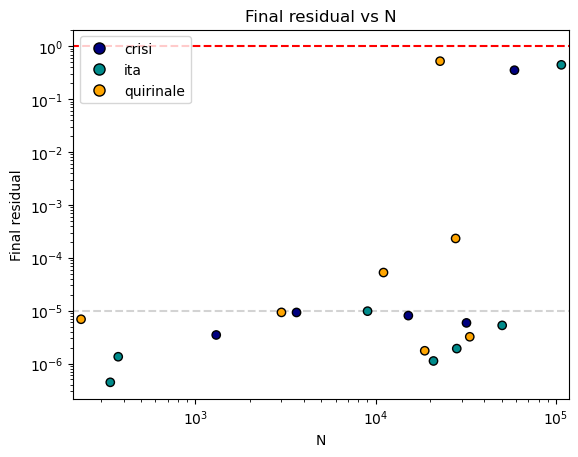

In [23]:
from matplotlib.lines import Line2D

plt.scatter(Ns, res_final, color=[color_dict[file.split('_')[0]] for file in qdecm_test_files], edgecolor='black', zorder=2)
plt.hlines([1e-5], 0.5*min(Ns), 1.5*max(Ns), linestyles='--', colors='lightgray', zorder=1)
plt.hlines([1], 0.5*min(Ns), 1.5*max(Ns), linestyles='--', colors='red', zorder=1)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('N')
plt.ylabel('Final residual')
plt.title('Final residual vs N')
plt.xlim(0.9*min(Ns), 1.1*max(Ns))

legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markeredgecolor='black', markersize=8, label=label)
    for label, color in color_dict.items()
]
plt.legend(handles=legend_handles)

plt.show()


Still unsatisfactory as some communities were exclude _a priori_ as they were too big.

### Is it related with some odd property of the network?

In [24]:
spearman_in=[spearmanr(model.k_in, model.s_in) for model in models]
spearman_out=[spearmanr(model.k_out, model.s_out) for model in models]

In [25]:
statistics_in=np.array([statistic for statistic, pvalue in spearman_in])
statistics_out=np.array([statistic for statistic, pvalue in spearman_out])  
p_in=np.array([pvalue for statistic, pvalue in spearman_in])
p_out=np.array([pvalue for statistic, pvalue in spearman_out])

In [26]:
max(p_in), max(p_out) # all entries are statistically validated

(2.7854416023046003e-80, 1.4752113043071724e-308)

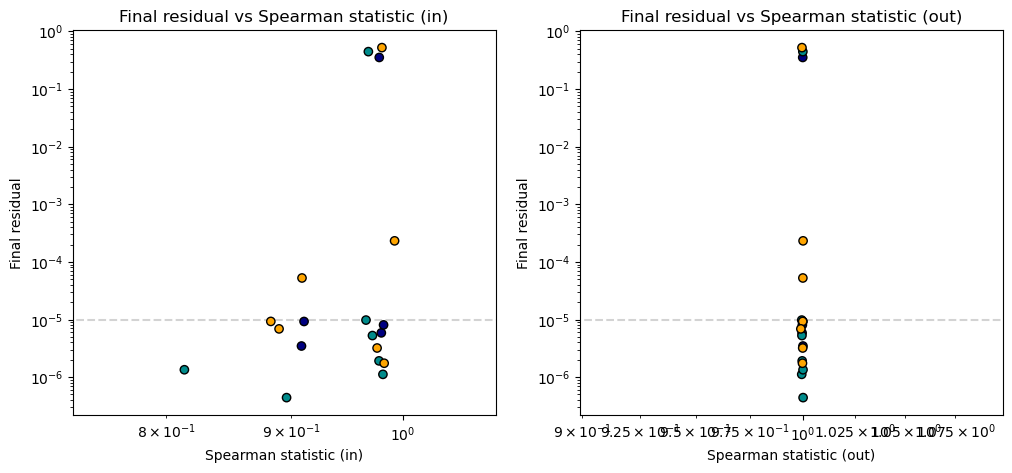

In [27]:
fig, axs=plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(statistics_in, res_final, color=[color_dict[file.split('_')[0]] for file in qdecm_test_files], zorder=2, marker='o', edgecolor='black')
axs[0].hlines([1e-5], 0.5*min(statistics_in), 1.5*max(statistics_in), linestyles='--', colors='lightgray', zorder=1)
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_xlabel('Spearman statistic (in)')
axs[0].set_ylabel('Final residual')
axs[0].set_title('Final residual vs Spearman statistic (in)')
axs[0].set_xlim(0.9*min(statistics_in), 1.1*max(statistics_in))

axs[1].scatter(statistics_out, res_final, color=[color_dict[file.split('_')[0]] for file in qdecm_test_files], zorder=2, marker='o', edgecolor='black')
axs[1].hlines([1e-5], 0.5*min(statistics_out), 1.5*max(statistics_out), linestyles='--', colors='lightgray', zorder=1)
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_xlabel('Spearman statistic (out)')
axs[1].set_ylabel('Final residual')
axs[1].set_title('Final residual vs Spearman statistic (out)')
axs[1].set_xlim(0.9*min(statistics_out), 1.1*max(statistics_out))

plt.show()

# Selecting non-converging communities

In [28]:
files

['crisi_dicos.csv',
 'crisi_weighted_edgelist.csv',
 'ita_elections_dicos.csv',
 'ita_elections_weighted_edgelist.csv',
 'quirinale_dicos.csv',
 'quirinale_weighted_edgelist.csv']

In [29]:
qdecm_filename_tests=[file for file in os.listdir(TEST_FOLDER) if file.endswith('_qdecm.pkl')]
qdecm_filename_tests.sort()
qdecm_filename_tests


['crisi_dico0_qdecm.pkl',
 'crisi_dico1_qdecm.pkl',
 'crisi_dico2_qdecm.pkl',
 'crisi_dico3_qdecm.pkl',
 'crisi_dico4_qdecm.pkl',
 'ita_elections_dico0_qdecm.pkl',
 'ita_elections_dico1_qdecm.pkl',
 'ita_elections_dico2_qdecm.pkl',
 'ita_elections_dico3_qdecm.pkl',
 'ita_elections_dico4_qdecm.pkl',
 'ita_elections_dico5_qdecm.pkl',
 'ita_elections_dico6_qdecm.pkl',
 'quirinale_dico0_qdecm.pkl',
 'quirinale_dico1_qdecm.pkl',
 'quirinale_dico2_qdecm.pkl',
 'quirinale_dico3_qdecm.pkl',
 'quirinale_dico4_qdecm.pkl',
 'quirinale_dico5_qdecm.pkl',
 'quirinale_dico6_qdecm.pkl']

In [30]:
bad_netwks={}
for qdecm_filename in qdecm_filename_tests:
    file_mtime = dt.date.fromtimestamp(os.path.getmtime(TEST_FOLDER+qdecm_filename))
    if file_mtime != dt.date.today():
        continue
    name=qdecm_filename.replace('_qdecm.pkl', '')
    with open(TEST_FOLDER + '/' + qdecm_filename, 'rb') as f:
        model=pickle.load(f)
    if hasattr(model, 'sol_weights') and hasattr(model.sol_weights, 'converged'):
        if not model.sol_weights.converged:
            bad_netwks[name] = {'k_out': model.k_out, 'k_in': model.k_in, 's_out': model.s_out, 's_in': model.s_in}


In [31]:
len(bad_netwks)

5

In [32]:
bad_netwks.keys()

dict_keys(['crisi_dico0', 'ita_elections_dico1', 'quirinale_dico1', 'quirinale_dico4', 'quirinale_dico5'])

In [33]:
with open(TEST_FOLDER + '/bad_netwks.pkl', 'wb') as f:
    pickle.dump(bad_netwks, f)